In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import serial
import copy
import queue
import threading

In [3]:
class VideoCapture:

  def __init__(self, name):
    self.cap = cv2.VideoCapture(name)
    self.q = queue.Queue()
    t = threading.Thread(target=self._reader)
    t.daemon = True
    t.start()

  # read frames as soon as they are available, keeping only most recent one
  def _reader(self):
    while True:
      ret, frame = self.cap.read()
      if not ret:
        break
      if not self.q.empty():
        try:
          self.q.get_nowait()   # discard previous (unprocessed) frame
        except queue.Empty:
          pass
      self.q.put(frame)

  def read(self):
    return self.q.get()

In [7]:
kamera1 = cv2.VideoCapture(5)
kamera2 = cv2.VideoCapture(6)

kamera1.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
kamera1.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)
kamera2.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
kamera2.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)
kamera1.set(cv2.CAP_PROP_BUFFERSIZE, 1)
kamera2.set(cv2.CAP_PROP_BUFFERSIZE, 1)


True

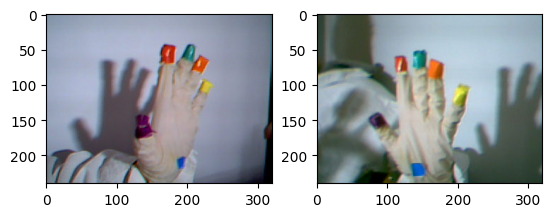

In [29]:
_, slika1i = kamera1.read()
_, slika2i = kamera2.read()
slika1i = cv2.cvtColor(slika1i, cv2.COLOR_BGR2RGB)
slika2i = cv2.cvtColor(slika2i, cv2.COLOR_BGR2RGB)
plot, ax = plt.subplots(1, 2)
ax[0].imshow(slika1i)

ax[1].imshow(slika2i)


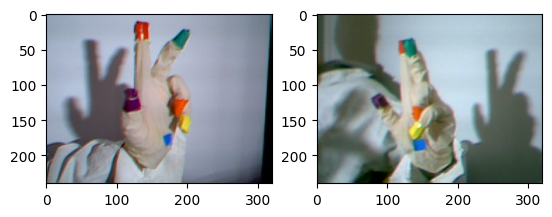

In [37]:
_, slika1 = kamera1.read()
_, slika2 = kamera2.read()
slika1 = cv2.cvtColor(slika1, cv2.COLOR_BGR2RGB)
slika2 = cv2.cvtColor(slika2, cv2.COLOR_BGR2RGB)
plot, ax = plt.subplots(1, 2)
ax[0].imshow(slika1)
ax[1].imshow(slika2)


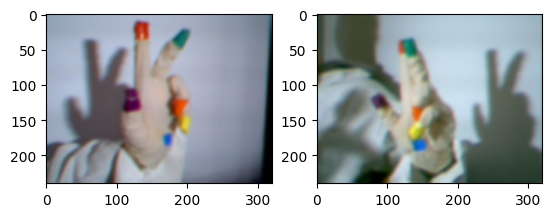

In [38]:
#slika1h = cv2.cvtColor(slika1, cv2.COLOR_RGB2HSV)
#slika2h = cv2.cvtColor(slika2, cv2.COLOR_RGB2HSV)
slika1h = slika1.copy()
slika2h = slika2.copy()
slika1h = cv2.GaussianBlur(slika1h, (15, 15), 2)
slika2h = cv2.GaussianBlur(slika2h, (15, 15), 2)
slika1f = cv2.cvtColor(slika1h, cv2.COLOR_RGB2LAB)
slika2f = cv2.cvtColor(slika2h, cv2.COLOR_RGB2LAB)
plot, ax = plt.subplots(1, 2)
ax[0].imshow(slika1h)
ax[1].imshow(slika2h)



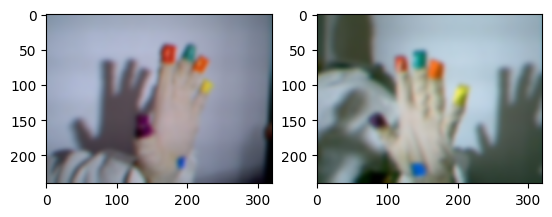

In [39]:
#slika1h = cv2.cvtColor(slika1, cv2.COLOR_RGB2HSV)
#slika2h = cv2.cvtColor(slika2, cv2.COLOR_RGB2HSV)
slika1hi = slika1i.copy()
slika2hi = slika2i.copy()
slika1hi = cv2.GaussianBlur(slika1hi, (15, 15), 3)
slika2hi = cv2.GaussianBlur(slika2hi, (15, 15), 3)
slika1fi = cv2.cvtColor(slika1hi, cv2.COLOR_RGB2LAB)
slika2fi = cv2.cvtColor(slika2hi, cv2.COLOR_RGB2LAB)
plot, ax = plt.subplots(1, 2)
ax[0].imshow(slika1hi)
ax[1].imshow(slika2hi)




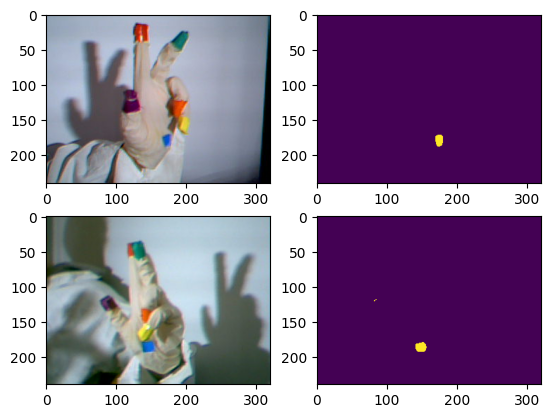

In [40]:

#odabir PLAVOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cr = np.array(slika1f.copy(), dtype=np.int32)
maska1r = 255*((np.arctan2(slika1cr[:,:,2]-128, slika1cr[:,:,1]-128) > -np.pi/2) & (np.arctan2(slika1cr[:,:,2]-128, slika1cr[:,:,1]-128) <= -np.pi/3.5) & (np.abs(slika1cr[:,:,1]-128 + 1j * (slika1cr[:,:,2]-128)) > 0.1*256))

slika2cr = np.array(slika2f.copy(), dtype=np.int32)
maska2r = 255*((np.arctan2(slika2cr[:,:,2]-128, slika2cr[:,:,1]-128) > -np.pi/2) & (np.arctan2(slika2cr[:,:,2]-128, slika2cr[:,:,1]-128) <= -np.pi/3.5) & (np.abs(slika2cr[:,:,1]-128 + 1j * (slika2cr[:,:,2]-128)) > 0.1*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1r)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2r)

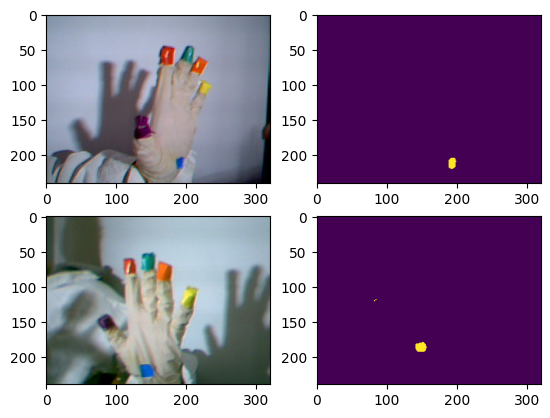

In [41]:

#odabir PLAVOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cir = np.array(slika1fi.copy(), dtype=np.int32)
maska1ir = 255*((np.arctan2(slika1cir[:,:,2]-128, slika1cir[:,:,1]-128) > -np.pi/2) & (np.arctan2(slika1cir[:,:,2]-128, slika1cir[:,:,1]-128) <= -np.pi/3.5) & (np.abs(slika1cir[:,:,1]-128 + 1j * (slika1cir[:,:,2]-128)) > 0.1*256))

slika2cir = np.array(slika2f.copy(), dtype=np.int32)
maska2ir = 255*((np.arctan2(slika2cir[:,:,2]-128, slika2cir[:,:,1]-128) > -np.pi/2) & (np.arctan2(slika2cir[:,:,2]-128, slika2cir[:,:,1]-128) <= -np.pi/3.5) & (np.abs(slika2cir[:,:,1]-128 + 1j * (slika2cir[:,:,2]-128)) > 0.1*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1ir)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2ir)

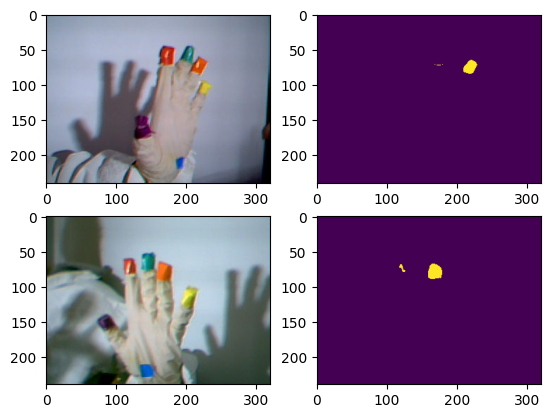

In [42]:

#odabir NARANDZASTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cin = np.array(slika1fi.copy(), dtype=np.int32)
maska1in = 255*((np.arctan2(slika1cin[:,:,2]-128, slika1cin[:,:,1]-128) > 1.5*np.pi/6) & (np.arctan2(slika1cin[:,:,2]-128, slika1cin[:,:,1]-128) <= 2*np.pi/6) & (np.abs(slika1cin[:,:,1]-128 + 1j * (slika1cin[:,:,2]-128)) > 0.15*256))

slika2cin = np.array(slika2fi.copy(), dtype=np.int32)
maska2in = 255*((np.arctan2(slika2cin[:,:,2]-128, slika2cin[:,:,1]-128) > 1.5*np.pi/6) & (np.arctan2(slika2cin[:,:,2]-128, slika2cin[:,:,1]-128) <= 2*np.pi/6) & (np.abs(slika2cin[:,:,1]-128 + 1j * (slika2cin[:,:,2]-128)) > 0.15*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1in)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2in)

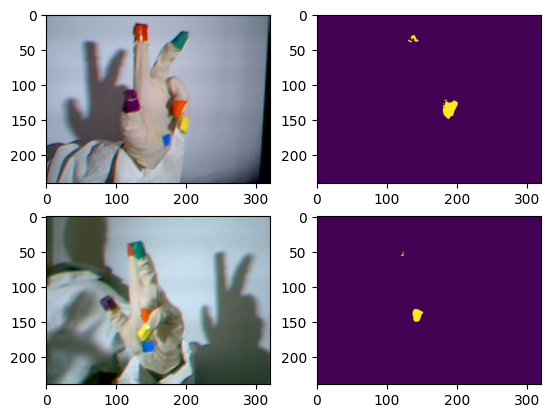

In [43]:

#odabir NARANDZASTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cn = np.array(slika1f.copy(), dtype=np.int32)
maska1n = 255*((np.arctan2(slika1cn[:,:,2]-128, slika1cn[:,:,1]-128) > 1.5*np.pi/6) & (np.arctan2(slika1cn[:,:,2]-128, slika1cn[:,:,1]-128) <= 2*np.pi/6) & (np.abs(slika1cn[:,:,1]-128 + 1j * (slika1cn[:,:,2]-128)) > 0.15*256))

slika2cn = np.array(slika2f.copy(), dtype=np.int32)
maska2n = 255*((np.arctan2(slika2cn[:,:,2]-128, slika2cn[:,:,1]-128) > 1.5*np.pi/6) & (np.arctan2(slika2cn[:,:,2]-128, slika2cn[:,:,1]-128) <= 2*np.pi/6) & (np.abs(slika2cn[:,:,1]-128 + 1j * (slika2cn[:,:,2]-128)) > 0.15*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1n)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2n)

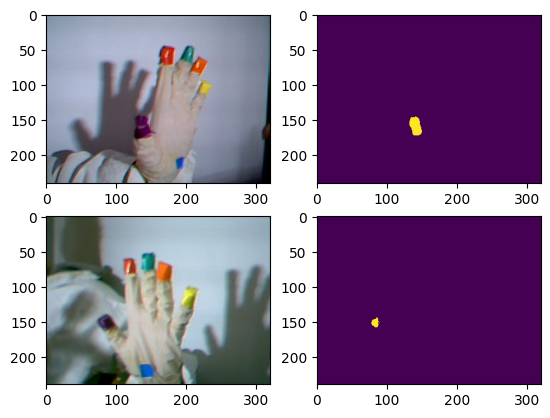

In [45]:

#odabir LJUBICASTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cil = np.array(slika1fi.copy(), dtype=np.int32)
maska1il = 255*((np.arctan2(slika1cil[:,:,2]-128, slika1cil[:,:,1]-128) > -1.5*np.pi/6) & (np.arctan2(slika1cil[:,:,2]-128, slika1cil[:,:,1]-128) <= -0.5*np.pi/6) & (np.abs(slika1cil[:,:,1]-128 + 1j * (slika1cil[:,:,2]-128)) > 0.12*256))

slika2cil = np.array(slika2fi.copy(), dtype=np.int32)
maska2il = 255*((np.arctan2(slika2cil[:,:,2]-128, slika2cil[:,:,1]-128) > -2*np.pi/6) & (np.arctan2(slika2cil[:,:,2]-128, slika2cil[:,:,1]-128) <= -0.5*np.pi/6) & (np.abs(slika2cil[:,:,1]-128 + 1j * (slika2cil[:,:,2]-128)) > 0.06*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1il)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2il)

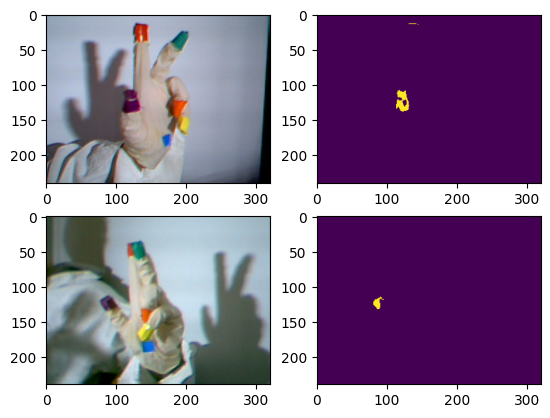

In [46]:

#odabir LJUBICASTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1cl = np.array(slika1f.copy(), dtype=np.int32)
maska1l = 255*((np.arctan2(slika1cl[:,:,2]-128, slika1cl[:,:,1]-128) > -1*np.pi/6) & (np.arctan2(slika1cl[:,:,2]-128, slika1cl[:,:,1]-128) <= -0.5*np.pi/6) & (np.abs(slika1cl[:,:,1]-128 + 1j * (slika1cl[:,:,2]-128)) > 0.08*256))

slika2cl = np.array(slika2f.copy(), dtype=np.int32)
maska2l = 255*((np.arctan2(slika2cl[:,:,2]-128, slika2cl[:,:,1]-128) > -2*np.pi/6) & (np.arctan2(slika2cl[:,:,2]-128, slika2cl[:,:,1]-128) <= -0.5*np.pi/6) & (np.abs(slika2cl[:,:,1]-128 + 1j * (slika2cl[:,:,2]-128)) > 0.06*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1l)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2l)

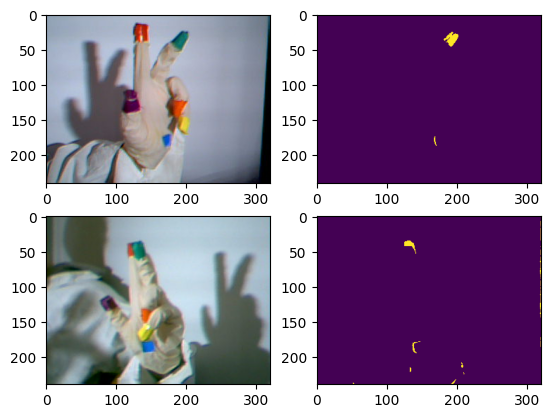

In [47]:

#odabir ZELENOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1c = np.array(slika1f.copy(), dtype=np.int32)
slika1g = np.zeros(slika1c.shape, dtype=np.uint8)
maska1g = 255*((np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) > -np.pi/1) & (np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) <= -np.pi/2) & (np.abs(slika1c[:,:,1]-128 + 1j * (slika1c[:,:,2]-128)) > 0.08*256))

slika2c = np.array(slika2f.copy(), dtype=np.int32)
slika2g = np.zeros(slika2c.shape, dtype=np.uint8)
maska2g = 255*((np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) > -np.pi/1) & (np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) <= -1.3*np.pi/2) & (np.abs(slika2c[:,:,1]-128 + 1j * (slika2c[:,:,2]-128)) > 0.06*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1g)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2g)

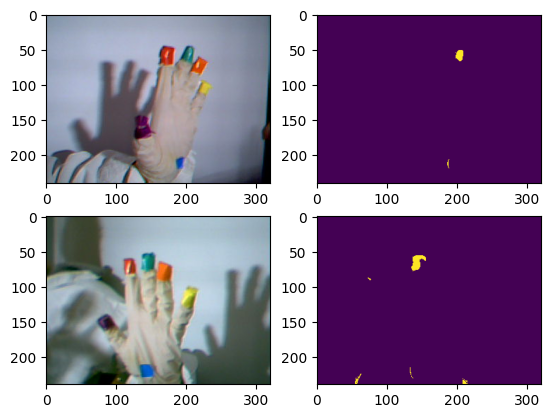

In [48]:

#odabir ZELENOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1ci = np.array(slika1fi.copy(), dtype=np.int32)
slika1ig = np.zeros(slika1ci.shape, dtype=np.uint8)
maska1ig = 255*((np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) > -np.pi/1) & (np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) <= -np.pi/2) & (np.abs(slika1ci[:,:,1]-128 + 1j * (slika1ci[:,:,2]-128)) > 0.08*256))

slika2ci = np.array(slika2fi.copy(), dtype=np.int32)
slika2ig = np.zeros(slika2ci.shape, dtype=np.uint8)
maska2ig = 255*((np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) > -np.pi/1) & (np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) <= -1.6*np.pi/2) & (np.abs(slika2ci[:,:,1]-128 + 1j * (slika2ci[:,:,2]-128)) > 0.05*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1ig)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2ig)

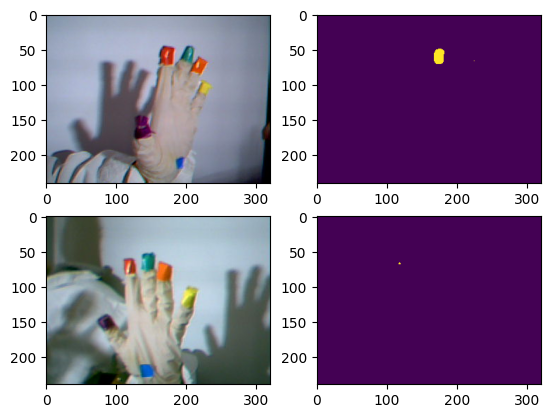

In [49]:

#odabir CRVENOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1ci = np.array(slika1fi.copy(), dtype=np.int32)
slika1ic = np.zeros(slika1ci.shape, dtype=np.uint8)
maska1ic = 255*((np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) > 0) & (np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) <= 1.5*np.pi/6) & (np.abs(slika1ci[:,:,1]-128 + 1j * (slika1ci[:,:,2]-128)) > 0.2*256))

slika2ci = np.array(slika2fi.copy(), dtype=np.int32)
slika2ic = np.zeros(slika2ci.shape, dtype=np.uint8)
maska2ic = 255*((np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) > 0) & (np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) <= 1.5*np.pi/6) & (np.abs(slika2ci[:,:,1]-128 + 1j * (slika2ci[:,:,2]-128)) > 0.2*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1ic)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2ic)

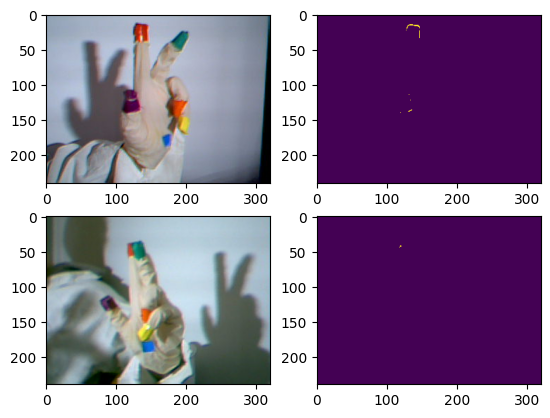

In [53]:

#odabir CRVENOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1c = np.array(slika1f.copy(), dtype=np.int32)
maska1c = 255*((np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) > 0) & (np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) <= np.pi/6) & (np.abs(slika1c[:,:,1]-128 + 1j * (slika1c[:,:,2]-128)) > 0.1*256))

slika2c = np.array(slika2f.copy(), dtype=np.int32)
maska2c = 255*((np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) > 0) & (np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) <= np.pi/6) & (np.abs(slika2c[:,:,1]-128 + 1j * (slika2c[:,:,2]-128)) > 0.08*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1c)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2c)

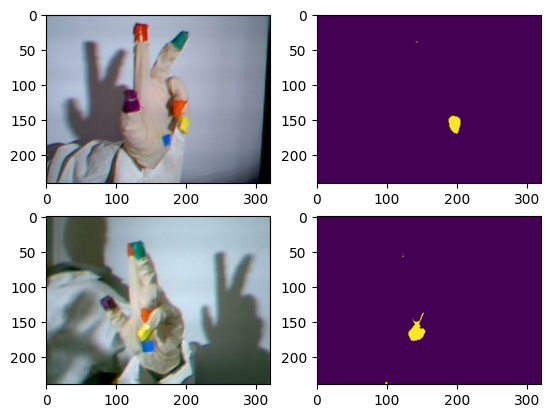

In [54]:

#odabir ZUTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1c = np.array(slika1f.copy(), dtype=np.int32)
slika1o = np.zeros(slika1c.shape, dtype=np.uint8)
maska1 = 255*((np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) > 2*np.pi/6) & (np.arctan2(slika1c[:,:,2]-128, slika1c[:,:,1]-128) <= 4*np.pi/6) & (np.abs(slika1c[:,:,1]-128 + 1j * (slika1c[:,:,2]-128)) > 0.13*256))

slika2c = np.array(slika2f.copy(), dtype=np.int32)
slika2o = np.zeros(slika2c.shape, dtype=np.uint8)
maska2 = 255*((np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) > 2*np.pi/6) & (np.arctan2(slika2c[:,:,2]-128, slika2c[:,:,1]-128) <= 4*np.pi/6) & (np.abs(slika2c[:,:,1]-128 + 1j * (slika2c[:,:,2]-128)) > 0.13*256))


ax[0,0].imshow(slika1)
ax[0,1].imshow(maska1)

ax[1,0].imshow(slika2)
ax[1,1].imshow(maska2)

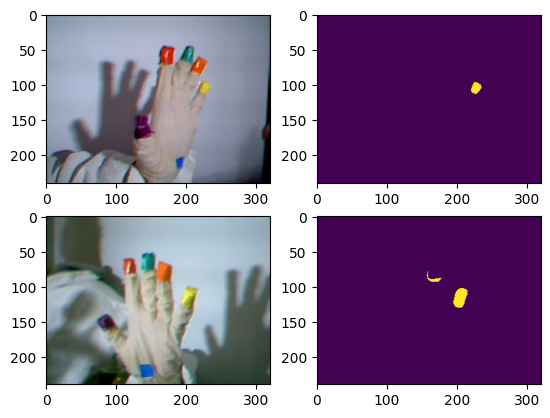

In [55]:

#odabir ZUTOG prsta u LAB prostoru boja

plot, ax = plt.subplots(2, 2)  

slika1ci = np.array(slika1fi.copy(), dtype=np.int32)
maska1i = 255*((np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) > 2*np.pi/6) & (np.arctan2(slika1ci[:,:,2]-128, slika1ci[:,:,1]-128) <= 4*np.pi/6) & (np.abs(slika1ci[:,:,1]-128 + 1j * (slika1ci[:,:,2]-128)) > 0.13*256))

slika2ci = np.array(slika2fi.copy(), dtype=np.int32)
maska2i = 255*((np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) > 2*np.pi/6) & (np.arctan2(slika2ci[:,:,2]-128, slika2ci[:,:,1]-128) <= 4*np.pi/6) & (np.abs(slika2ci[:,:,1]-128 + 1j * (slika2ci[:,:,2]-128)) > 0.13*256))


ax[0,0].imshow(slika1i)
ax[0,1].imshow(maska1i)

ax[1,0].imshow(slika2i)
ax[1,1].imshow(maska2i)

In [56]:
#centar mase REFERENTNE tacke

kr1 = np.argwhere(maska1r)
kir1 = np.argwhere(maska1ir)

kr2 = np.argwhere(maska2r)
kir2 = np.argwhere(maska2ir)

cxr1 = np.mean(kr1[:,1])
cyr1 = np.mean(kr1[:,0])

cxir1 = np.mean(kir1[:,1])
cyir1 = np.mean(kir1[:,0])

cxr2 = np.mean(kr2[:,1])
cyr2 = np.mean(kr2[:,0])

cxir2 = np.mean(kir2[:,1])
cyir2 = np.mean(kir2[:,0])

In [57]:
#centar mase ZUTE tacke

kz1 = np.argwhere(maska1)
kiz1 = np.argwhere(maska1i)

kz2 = np.argwhere(maska2)
kiz2 = np.argwhere(maska2i)

cxz1 = np.mean(kz1[:,1])
cyz1 = np.mean(kz1[:,0])

cxiz1 = np.mean(kiz1[:,1])
cyiz1 = np.mean(kiz1[:,0])

cxz2 = np.mean(kz2[:,1])
cyz2 = np.mean(kz2[:,0])

cxiz2 = np.mean(kiz2[:,1])
cyiz2 = np.mean(kiz2[:,0])

print(cxz2, cyz2)

140.53812636165577 165.03267973856208


In [58]:
#centar mase NARANDZASTE tacke

kn1 = np.argwhere(maska1n)
kin1 = np.argwhere(maska1in)

kn2 = np.argwhere(maska2n)
kin2 = np.argwhere(maska2in)

cxn1 = np.mean(kn1[:,1])
cyn1 = np.mean(kn1[:,0])

cxin1 = np.mean(kin1[:,1])
cyin1 = np.mean(kin1[:,0])

cxn2 = np.mean(kn2[:,1])
cyn2 = np.mean(kn2[:,0])

cxin2 = np.mean(kin2[:,1])
cyin2 = np.mean(kin2[:,0])

print(cxn2, cyn2)

140.9368932038835 136.77184466019418


In [59]:
#centar mase LJUBICASTE tacke

kl1 = np.argwhere(maska1l)
kil1 = np.argwhere(maska1il)

kl2 = np.argwhere(maska2l)
kil2 = np.argwhere(maska2il)

cxl1 = np.mean(kl1[:,1])
cyl1 = np.mean(kl1[:,0])

cxil1 = np.mean(kil2[:,1])
cyil1 = np.mean(kil1[:,0])

cxl2 = np.mean(kl2[:,1])
cyl2 = np.mean(kl2[:,0])

cxil2 = np.mean(kil2[:,1])
cyil2 = np.mean(kil2[:,0])

print(cxl2, cyl2, cxr2, cyr2)
print(cxil2, cyil2, cxir2, cyir2)
print(cxl1, cyl1, cxr1, cyr2)
print(cxil1, cyil1, cxir1, cyir1)

85.60317460317461 123.88888888888889 145.64171122994654 185.0909090909091
82.4952380952381 151.93333333333334 145.64171122994654 185.0909090909091
122.02191780821917 119.18630136986302 174.09375 185.0909090909091
82.4952380952381 158.2619718309859 192.63888888888889 211.25694444444446


In [60]:
#centar mase ZELENE tacke

kg1 = np.argwhere(maska1g)
kig1 = np.argwhere(maska1ig)

kg2 = np.argwhere(maska2g)
kig2 = np.argwhere(maska2ig)

cxg1 = np.mean(kg1[:,1])
cyg1 = np.mean(kg1[:,0])

cxig1 = np.mean(kig2[:,1])
cyig1 = np.mean(kig1[:,0])

cxg2 = np.mean(kg2[:,1])
cyg2 = np.mean(kg2[:,0])

cxig2 = np.mean(kig2[:,1])
cyig2 = np.mean(kig2[:,0])

print(cxg2, cyg2)

250.0204081632653 100.3747680890538


In [61]:
#centar mase CRVENE tacke

kc1 = np.argwhere(maska1c)
kic1 = np.argwhere(maska1ic)

kc2 = np.argwhere(maska2c)
kic2 = np.argwhere(maska2ic)

cxc1 = np.mean(kc1[:,1])
cyc1 = np.mean(kc1[:,0])

cxic1 = np.mean(kic2[:,1])
cyic1 = np.mean(kic1[:,0])

#cxc2 = np.mean(kc2[:,1])
#cyc2 = np.mean(kc2[:,0])

cxic2 = np.mean(kic2[:,1])
cyic2 = np.mean(kic2[:,0])

cxc2 = cxg2
cyc2 = cyg2

print(cxc2, cyc2)

250.0204081632653 100.3747680890538


In [62]:
#trijangulacija REFERENTNE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyir1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxir1)*kameraA[2],
    (cyir2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxir2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazir1 = trazeni[:3]/trazeni[-1]
print(izlazir1)

[ 0.9573185   0.92604454 -0.1903315 ]


In [63]:
#trijangulacija ZUTE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyiz1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxiz1)*kameraA[2],
    (cyiz2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxiz2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlaziz1 = trazeni[:3]/trazeni[-1]
print(izlaziz1)

[1.07687828 0.81331455 0.03116807]


In [64]:
#trijangulacija NARANDZASTE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyin1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxin1)*kameraA[2],
    (cyin2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxin2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazin1 = trazeni[:3]/trazeni[-1]
print(izlazin1)

[1.00363416 0.85258911 0.10508008]


In [65]:
#trijangulacija LJUBICASTE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyil1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxil1)*kameraA[2],
    (cyil2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxil2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazil1 = trazeni[:3]/trazeni[-1]
print(izlazil1)

[ 0.76924224  1.1543465  -0.0855825 ]


In [66]:
#trijangulacija ZELENE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyig1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxig1)*kameraA[2],
    (cyig2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxig2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazig1 = trazeni[:3]/trazeni[-1]
print(izlazig1)

[0.93389593 1.05813538 0.07122855]


In [67]:
#trijangulacija CRVENE tacke u POCETNOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyic1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxic1)*kameraA[2],
    (cyic2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxic2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazic1 = trazeni[:3]/trazeni[-1]
print(izlazic1)

[0.87846298 1.09769095 0.14421244]


In [68]:
#trijangulacija REFERENTNE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyr1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxr1)*kameraA[2],
    (cyr2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxr2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazr1 = trazeni[:3]/trazeni[-1]
print(izlazr1)

[ 0.96535376  0.96338348 -0.15386594]


In [69]:
#trijangulacija ZUTE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyz1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxz1)*kameraA[2],
    (cyz2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxz2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazz1 = trazeni[:3]/trazeni[-1]
print(izlazz1)

[ 0.95526196  0.90990832 -0.09501637]


In [70]:
#trijangulacija NARANDZASTE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyn1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxn1)*kameraA[2],
    (cyn2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxn2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazn1 = trazeni[:3]/trazeni[-1]
print(izlazn1)

[ 0.95369324  0.94495794 -0.02019984]


In [71]:
#trijangulacija LJUBICASTE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyl1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxl1)*kameraA[2],
    (cyl2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxl2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazl1 = trazeni[:3]/trazeni[-1]
print(izlazl1)

[ 0.79239395  1.07830102 -0.00461644]


In [72]:
#trijangulacija ZELENE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyg1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxg1)*kameraA[2],
    (cyg2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxg2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazg1 = trazeni[:3]/trazeni[-1]
print(izlazg1)

[1.20126389 0.91364292 0.13576382]


In [73]:
#trijangulacija CRVENE tacke u KRAJNJOJ slici

kameraB = np.array([[1, 0, 0, -1], [0, 0, -1, 0], [0, 1, 0, 0]])
kameraB = np.dot(0.5*np.array([[772.81013182, 0, 320],[0, 779.95788961, 240 ],[0,0,2]]), kameraB)
kameraA = np.array([[0, -1, 0, 1], [0, 0, -1, 0], [1, 0, 0, 0]])
kameraA = np.dot(0.5*np.array([[768.3329645, 0, 320],[0, 770.36287522, 240 ],[0,0,2]]), kameraA)

A = np.array([
    (cyc1)*kameraA[2] - kameraA[1],
    kameraA[0] - (cxc1)*kameraA[2],
    (cyc2)*kameraB[2] - kameraB[1],
    kameraB[0] - (cxc2)*kameraB[2],
])

U, S, Vt = np.linalg.svd(A)

trazeni = Vt[-1]

izlazc1 = trazeni[:3]/trazeni[-1]
print(izlazc1)

[1.23747547 1.08103583 0.15799414]


In [74]:
P = izlaziz1 - izlazir1
R = izlazz1 - izlazr1

Pp = (R@P)/(P@P)

print(Pp)

P = izlazin1 - izlazir1
R = izlazn1 - izlazr1

Kp = (np.dot(P,R))/(np.dot(P,P))

print(Kp)


P = izlazil1 - izlazir1
R = izlazl1 - izlazr1

Sp = (np.dot(P,R))/(np.dot(P,P))

print(Sp)


P = izlazig1 - izlazir1
R = izlazg1 - izlazr1

Dp = (np.dot(P,R))/(np.dot(P,P))

print(Dp)


P = izlazic1 - izlazir1
R = izlazc1 - izlazr1

Mp = (np.dot(P,R))/(np.dot(P,P))

print(Mp)


0.23475862705150935
0.4250648106136162
0.7555770626495528
0.7367142838206623
0.698285713102023


In [75]:
def palacFja(x):
  return 0.56*np.sin(2.02*x+1.62)+0.449
def kaziprstFja(x):
  return 0.29*np.sin(2.89*x+1.87)+0.71
def srednjakFja(x):
  return 0.33*np.sin(2.46*x+1.94)+0.67
def domaliFja(x):
  return 0.38*np.sin(3.25*x+1.89)+0.64
def maliFja(x):
  return -0.45*x**2 -0.13*x + 0.99

In [76]:

palacModel = palacFja(np.linspace(0, 1, 180))
kaziprstModel = kaziprstFja(np.linspace(0, 0.9859, 176))
srednjakModel = srednjakFja(np.linspace(0, 1, 180))
domaliModel = domaliFja(np.linspace(0, 0.8684, 156))
maliModel = maliFja(np.linspace(0, 1, 180))

In [77]:
import bisect

In [78]:
izlazi = np.zeros(5, dtype=np.uint8)
izlazi[0] = bisect.bisect(-palacModel, -Pp)
izlazi[1] = bisect.bisect(-kaziprstModel, -Kp)
izlazi[2] = bisect.bisect(-srednjakModel, -Sp)
izlazi[3] = bisect.bisect(-domaliModel, -Dp)
izlazi[4] = bisect.bisect(-maliModel, -Mp)
komanda = "".join([f"{x:03}" for x in izlazi]) + "\n"; print("OBRADA: "+komanda)

OBRADA: 170164069055121



In [79]:
arduino = serial.Serial(port='/dev/ttyACM0', baudrate=115200, timeout=.2)
arduino.write(bytes(komanda, 'ascii'))

16